In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('data/PS4_GamesSales.csv', encoding='windows-1252')

# Basic data exploration
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (1034, 9)

First few rows:
                        Game    Year             Genre       Publisher  \
0         Grand Theft Auto V  2014.0            Action  Rockstar Games   
1  Call of Duty: Black Ops 3  2015.0           Shooter      Activision   
2      Red Dead Redemption 2  2018.0  Action-Adventure  Rockstar Games   
3         Call of Duty: WWII  2017.0           Shooter      Activision   
4                    FIFA 18  2017.0            Sports       EA Sports   

   North America  Europe  Japan  Rest of World  Global  
0           6.06    9.71   0.60           3.02   19.39  
1           6.18    6.05   0.41           2.44   15.09  
2           5.26    6.21   0.21           2.26   13.94  
3           4.67    6.21   0.40           2.12   13.40  
4           1.27    8.64   0.15           1.73   11.80  

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  --

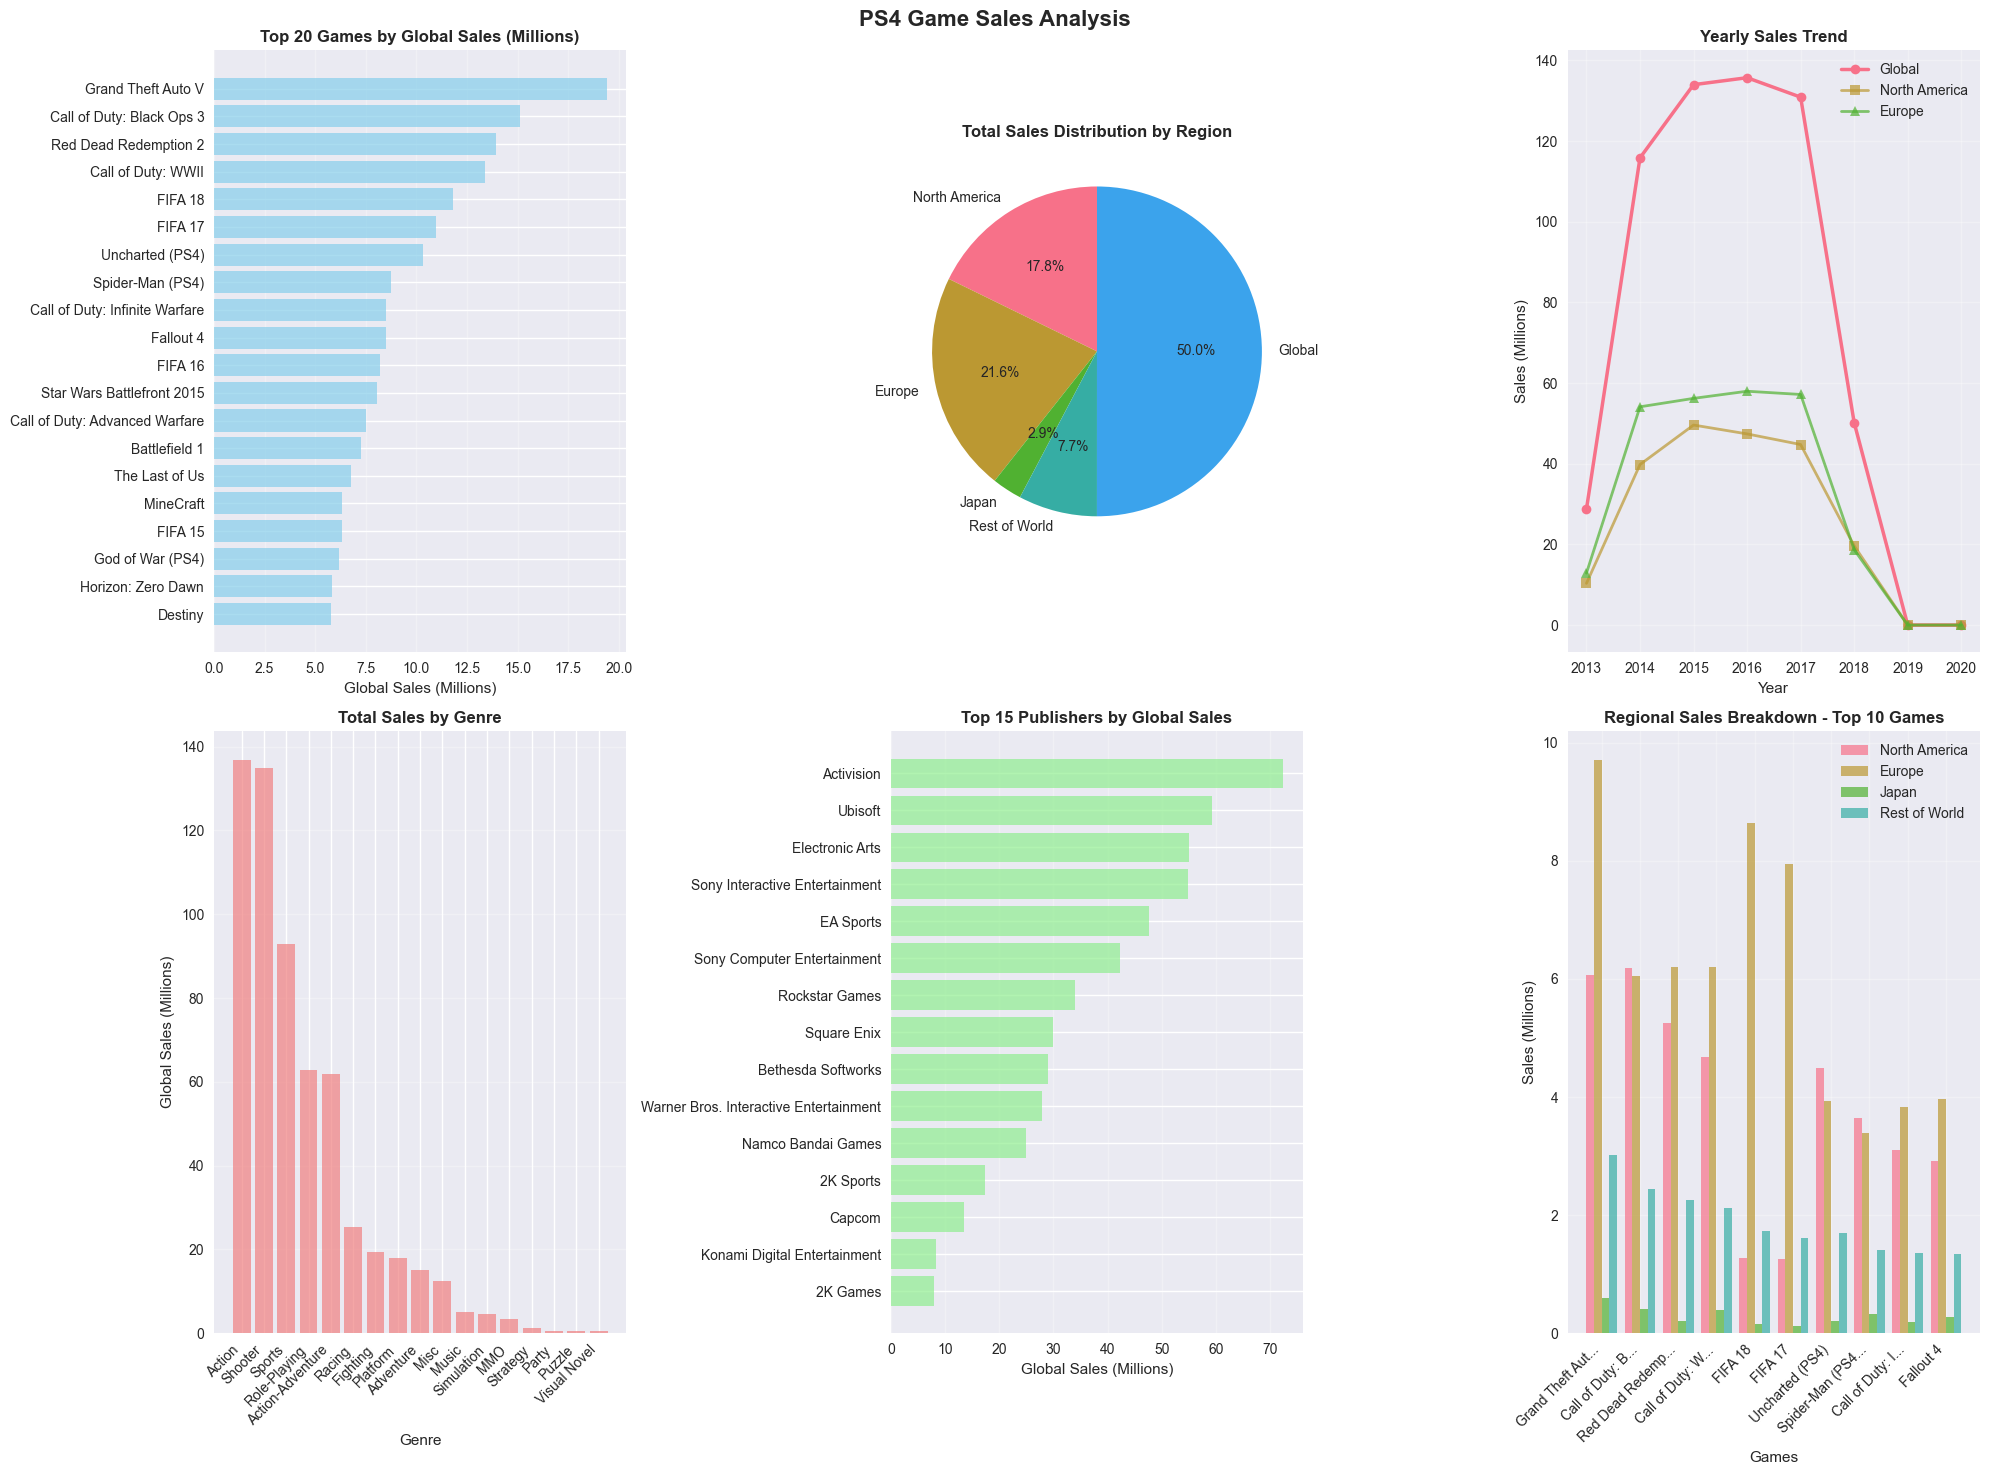

In [5]:
# Create a comprehensive analysis with multiple visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
fig.suptitle('PS4 Game Sales Analysis', fontsize=16, fontweight='bold')

# 1. Top 20 Games by Global Sales
top_games = df.nlargest(20, 'Global')[['Game', 'Global']].sort_values('Global', ascending=True)
axes[0, 0].barh(top_games['Game'], top_games['Global'], color='skyblue', alpha=0.7)
axes[0, 0].set_title('Top 20 Games by Global Sales (Millions)', fontweight='bold')
axes[0, 0].set_xlabel('Global Sales (Millions)')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Sales Distribution by Region
regions = ['North America', 'Europe', 'Japan', 'Rest of World', 'Global']
region_sales = df[regions].sum()
axes[0, 1].pie(region_sales, labels=regions, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Total Sales Distribution by Region', fontweight='bold')

# 3. Yearly Sales Trend
yearly_sales = df.groupby('Year')[regions].sum()
axes[0, 2].plot(yearly_sales.index, yearly_sales['Global'], marker='o', linewidth=2.5, label='Global')
axes[0, 2].plot(yearly_sales.index, yearly_sales['North America'], marker='s', linewidth=2, label='North America', alpha=0.7)
axes[0, 2].plot(yearly_sales.index, yearly_sales['Europe'], marker='^', linewidth=2, label='Europe', alpha=0.7)
axes[0, 2].set_title('Yearly Sales Trend', fontweight='bold')
axes[0, 2].set_xlabel('Year')
axes[0, 2].set_ylabel('Sales (Millions)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Genre Analysis
genre_sales = df.groupby('Genre')['Global'].sum().sort_values(ascending=False)
axes[1, 0].bar(range(len(genre_sales)), genre_sales.values, color='lightcoral', alpha=0.7)
axes[1, 0].set_title('Total Sales by Genre', fontweight='bold')
axes[1, 0].set_xlabel('Genre')
axes[1, 0].set_ylabel('Global Sales (Millions)')
axes[1, 0].set_xticks(range(len(genre_sales)))
axes[1, 0].set_xticklabels(genre_sales.index, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Top Publishers
publisher_sales = df.groupby('Publisher')['Global'].sum().nlargest(15).sort_values(ascending=True)
axes[1, 1].barh(publisher_sales.index, publisher_sales.values, color='lightgreen', alpha=0.7)
axes[1, 1].set_title('Top 15 Publishers by Global Sales', fontweight='bold')
axes[1, 1].set_xlabel('Global Sales (Millions)')
axes[1, 1].grid(axis='x', alpha=0.3)

# 6. Regional Sales Comparison for Top Games
top_10_games = df.nlargest(10, 'Global')
games = top_10_games['Game']
x = np.arange(len(games))
width = 0.2

axes[1, 2].bar(x - width*1.5, top_10_games['North America'], width, label='North America', alpha=0.7)
axes[1, 2].bar(x - width/2, top_10_games['Europe'], width, label='Europe', alpha=0.7)
axes[1, 2].bar(x + width/2, top_10_games['Japan'], width, label='Japan', alpha=0.7)
axes[1, 2].bar(x + width*1.5, top_10_games['Rest of World'], width, label='Rest of World', alpha=0.7)

axes[1, 2].set_title('Regional Sales Breakdown - Top 10 Games', fontweight='bold')
axes[1, 2].set_xlabel('Games')
axes[1, 2].set_ylabel('Sales (Millions)')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels([game[:15] + '...' if len(game) > 15 else game for game in games], rotation=45, ha='right')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

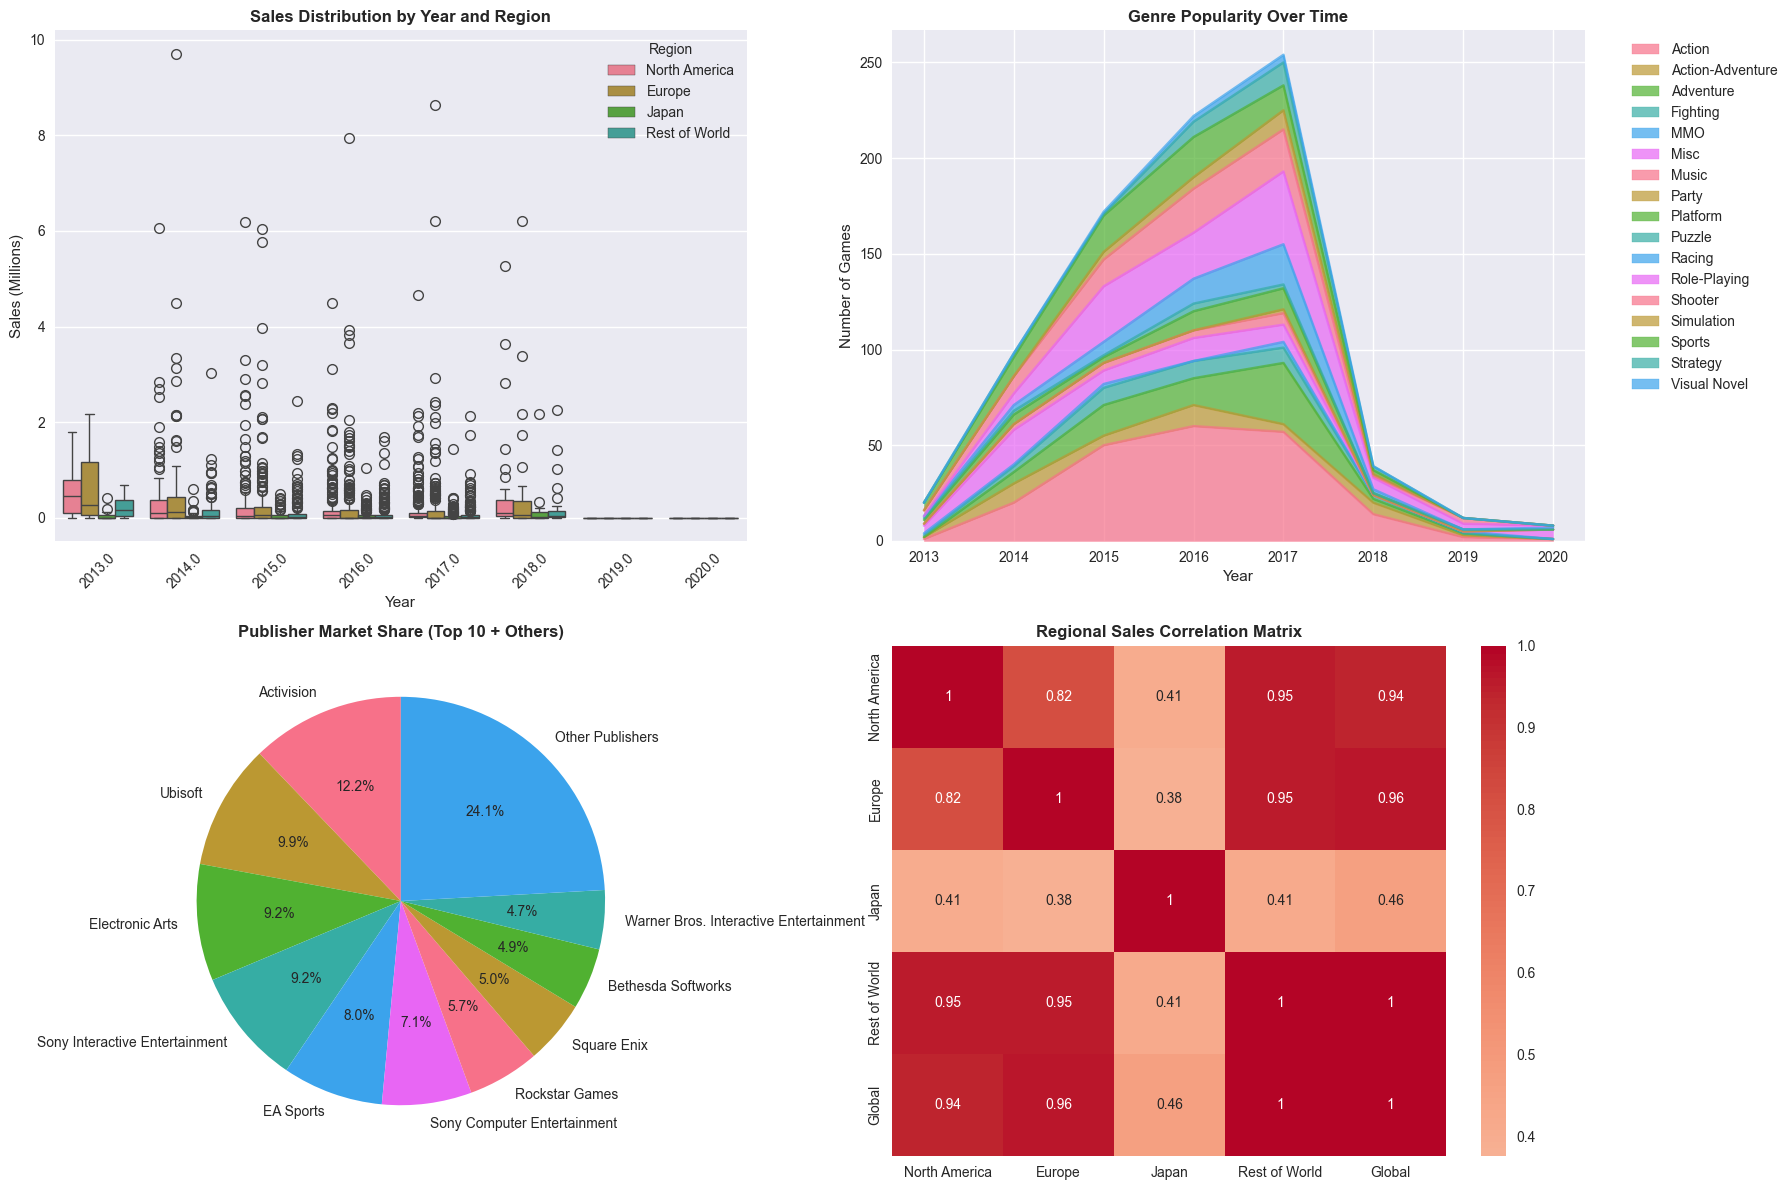

In [6]:
# Additional detailed analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Sales Distribution by Year (Box plot)
df_melted = df.melt(id_vars=['Year'], value_vars=['North America', 'Europe', 'Japan', 'Rest of World'], 
                   var_name='Region', value_name='Sales')
sns.boxplot(data=df_melted, x='Year', y='Sales', hue='Region', ax=axes[0, 0])
axes[0, 0].set_title('Sales Distribution by Year and Region', fontweight='bold')
axes[0, 0].set_ylabel('Sales (Millions)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Genre Popularity Over Time
genre_year = df.groupby(['Year', 'Genre']).size().unstack(fill_value=0)
genre_year.plot(kind='area', stacked=True, ax=axes[0, 1], alpha=0.7)
axes[0, 1].set_title('Genre Popularity Over Time', fontweight='bold')
axes[0, 1].set_ylabel('Number of Games')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Publisher Market Share
top_publishers = df.groupby('Publisher')['Global'].sum().nlargest(10)
other_sales = df['Global'].sum() - top_publishers.sum()
market_share = pd.concat([top_publishers, pd.Series({'Other Publishers': other_sales})])
axes[1, 0].pie(market_share.values, labels=market_share.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Publisher Market Share (Top 10 + Others)', fontweight='bold')

# 4. Correlation Heatmap of Regional Sales
correlation_matrix = df[['North America', 'Europe', 'Japan', 'Rest of World', 'Global']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Regional Sales Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Statistical Summary and Insights
print("=" * 60)
print("PS4 GAME SALES - KEY INSIGHTS")
print("=" * 60)

# Basic statistics
print(f"\n📊 DATASET OVERVIEW:")
print(f"Total Games: {len(df)}")
print(f"Years Covered: {df['Year'].min()} - {df['Year'].max()}")
print(f"Unique Publishers: {df['Publisher'].nunique()}")
print(f"Unique Genres: {df['Genre'].nunique()}")

# Top performers
print(f"\n🏆 TOP PERFORMERS:")
print(f"Best Selling Game: {df.loc[df['Global'].idxmax(), 'Game']} ({df['Global'].max():.2f}M)")
print(f"Most Prolific Publisher: {df['Publisher'].value_counts().index[0]} ({df['Publisher'].value_counts().iloc[0]} games)")
print(f"Most Common Genre: {df['Genre'].value_counts().index[0]} ({df['Genre'].value_counts().iloc[0]} games)")

# Regional analysis
print(f"\n🌍 REGIONAL ANALYSIS:")
for region in ['North America', 'Europe', 'Japan', 'Rest of World']:
    print(f"{region}: {df[region].sum():.2f}M total sales")

# Yearly performance
print(f"\n📈 YEARLY PERFORMANCE:")
best_year = df.groupby('Year')['Global'].sum().idxmax()
worst_year = df.groupby('Year')['Global'].sum().idxmin()
print(f"Best Year: {best_year} ({df.groupby('Year')['Global'].sum().max():.2f}M)")
print(f"Worst Year: {worst_year} ({df.groupby('Year')['Global'].sum().min():.2f}M)")

# Publisher dominance
print(f"\n🏢 PUBLISHER DOMINANCE:")
top_5_publishers = df.groupby('Publisher')['Global'].sum().nlargest(5)
for i, (publisher, sales) in enumerate(top_5_publishers.items(), 1):
    print(f"{i}. {publisher}: {sales:.2f}M")

# Genre performance
print(f"\n🎮 GENRE PERFORMANCE:")
top_5_genres = df.groupby('Genre')['Global'].sum().nlargest(5)
for i, (genre, sales) in enumerate(top_5_genres.items(), 1):
    print(f"{i}. {genre}: {sales:.2f}M")

PS4 GAME SALES - KEY INSIGHTS

📊 DATASET OVERVIEW:
Total Games: 1034
Years Covered: 2013.0 - 2020.0
Unique Publishers: 152
Unique Genres: 17

🏆 TOP PERFORMERS:
Best Selling Game: Grand Theft Auto V (19.39M)
Most Prolific Publisher: Namco Bandai Games (56 games)
Most Common Genre: Action (258 games)

🌍 REGIONAL ANALYSIS:
North America: 211.57M total sales
Europe: 257.17M total sales
Japan: 34.78M total sales
Rest of World: 92.04M total sales

📈 YEARLY PERFORMANCE:
Best Year: 2016.0 (135.72M)
Worst Year: 2019.0 (0.00M)

🏢 PUBLISHER DOMINANCE:
1. Activision: 72.44M
2. Ubisoft: 59.16M
3. Electronic Arts: 54.96M
4. Sony Interactive Entertainment: 54.85M
5. EA Sports: 47.55M

🎮 GENRE PERFORMANCE:
1. Action: 136.85M
2. Shooter: 134.99M
3. Sports: 92.85M
4. Role-Playing: 62.82M
5. Action-Adventure: 61.86M


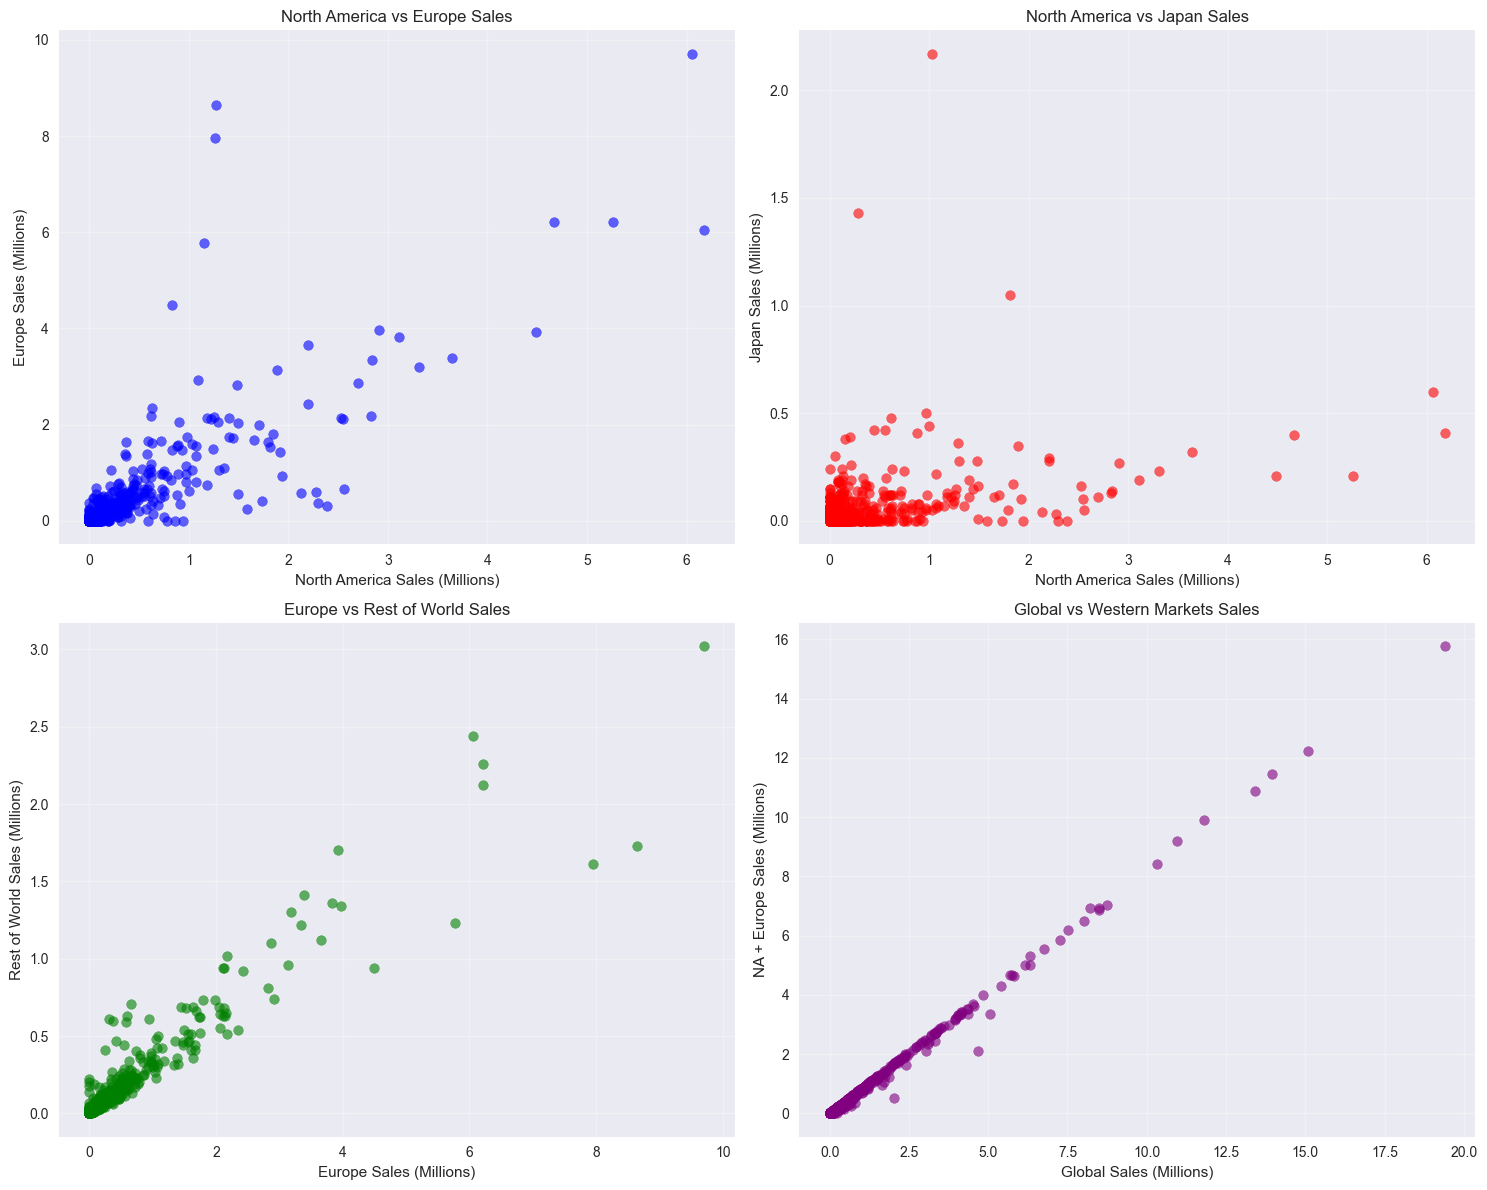


ANALYSIS COMPLETE


In [8]:
# Scatter plot matrix to show relationships between regions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# North America vs Europe
axes[0, 0].scatter(df['North America'], df['Europe'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('North America Sales (Millions)')
axes[0, 0].set_ylabel('Europe Sales (Millions)')
axes[0, 0].set_title('North America vs Europe Sales')
axes[0, 0].grid(True, alpha=0.3)

# North America vs Japan
axes[0, 1].scatter(df['North America'], df['Japan'], alpha=0.6, color='red')
axes[0, 1].set_xlabel('North America Sales (Millions)')
axes[0, 1].set_ylabel('Japan Sales (Millions)')
axes[0, 1].set_title('North America vs Japan Sales')
axes[0, 1].grid(True, alpha=0.3)

# Europe vs Rest of World
axes[1, 0].scatter(df['Europe'], df['Rest of World'], alpha=0.6, color='green')
axes[1, 0].set_xlabel('Europe Sales (Millions)')
axes[1, 0].set_ylabel('Rest of World Sales (Millions)')
axes[1, 0].set_title('Europe vs Rest of World Sales')
axes[1, 0].grid(True, alpha=0.3)

# Global vs Regional correlation
axes[1, 1].scatter(df['Global'], df['North America'] + df['Europe'], alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Global Sales (Millions)')
axes[1, 1].set_ylabel('NA + Europe Sales (Millions)')
axes[1, 1].set_title('Global vs Western Markets Sales')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)